# Машинное обучение, ФКН ВШЭ

## Практическое задание 11. Метод опорных векторов и аппроксимация ядер

### Общая информация

Дата выдачи: 06.05.2026

Мягкий дедлайн: 23:59MSK 18.05.2026

Жесткий дедлайн: 23:59MSK 23.05.2026

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимальная оценка за работу (без учёта бонусов) — 10 баллов. Всего за работу с бонусами можно набрать 12.75 баллов.

Сдавать задание после указанного жёсткого срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник). 

Использование генеративных языковых моделей разрешено только в случае явного указания на это. Необходимо прописать (в соответствующих пунктах, где использовались, либо в начале/конце работы):
- какая языковая модель использовалась
- какие использовались промпты и в каких частях работы
- с какими сложностями вы столкнулись при использовании генеративных моделей, с чем они помогли больше всего

Неэффективная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-11-random-features-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

### О задании

На занятиях мы подробно обсуждали метод опорных векторов (SVM). В базовой версии в нём нет чего-то особенного — мы всего лишь используем специальную функцию потерь, которая не требует устремлять отступы к бесконечности; ей достаточно, чтобы отступы были не меньше +1. Затем мы узнали, что SVM можно переписать в двойственном виде, который, позволяет заменить скалярные произведения объектов на ядра. Это будет соответствовать построению модели в новом пространстве более высокой размерности, координаты которого представляют собой нелинейные модификации исходных признаков.

Ядровой SVM, к сожалению, довольно затратен по памяти (нужно хранить матрицу Грама размера $d \times d$) и по времени (нужно решать задачу условной оптимизации с квадратичной функцией, а это не очень быстро). Мы обсуждали, что есть способы посчитать новые признаки $\tilde \varphi(x)$ на основе исходных так, что скалярные произведения этих новых $\langle \tilde \varphi(x), \tilde \varphi(z) \rangle$ приближают ядро $K(x, z)$.

Мы будем исследовать аппроксимации методом Random Fourier Features (RFF, также в литературе встречается название Random Kitchen Sinks) для гауссовых ядер. Будем использовать формулы, которые немного отличаются от того, что было на лекциях (мы добавим сдвиги внутрь тригонометрических функций и будем использовать только косинусы, потому что с нужным сдвигом косинус превратится в синус):
$$\tilde \varphi(x) = (
\cos (w_1^T x + b_1),
\dots,
\cos (w_n^T x + b_n)
),$$
где $w_j \sim \mathcal{N}(0, 1/\sigma^2)$, $b_j \sim U[-\pi, \pi]$.

На новых признаках $\tilde \varphi(x)$ мы будем строить любую линейную модель.

Можно считать, что это некоторая новая парадигма построения сложных моделей. Можно направленно искать сложные нелинейные закономерности в данных с помощью градиентного бустинга или нейронных сетей, а можно просто нагенерировать большое количество случайных нелинейных признаков и надеяться, что быстрая и простая модель (то есть линейная) сможет показать на них хорошее качество. В этом задании мы изучим, насколько работоспособна такая идея.

### Алгоритм

Вам потребуется реализовать следующий алгоритм:
1. Понизить размерность выборки до new_dim с помощью метода главных компонент.
2. Для полученной выборки оценить гиперпараметр $\sigma^2$ с помощью эвристики (рекомендуем считать медиану не по всем парам объектов, а по случайному подмножеству из где-то миллиона пар объектов): $$\sigma^2 = \text{median}_{i, j = 1, \dots, \ell, i \neq j} \left\{\sum_{k = 1}^{d} (x_{ik} - x_{jk})^2 \right\}$$
3. Сгенерировать n_features наборов весов $w_j$ и сдвигов $b_j$.
4. Сформировать n_features новых признаков по формулам, приведённым выше.
5. Обучить линейную модель (логистическую регрессию или SVM) на новых признаках.
6. Повторить преобразования (PCA, формирование новых признаков) к тестовой выборке и применить модель.

In [1]:
%load_ext autoreload
%autoreload 2

Тестировать алгоритм мы будем на данных Fashion MNIST. Ниже код для их загрузки и подготовки.

In [2]:
import numpy as np

# 1 Способ
import keras
from keras.datasets import fashion_mnist
(x_train_pics, y_train), (x_test_pics, y_test) = fashion_mnist.load_data()

# 2 Способ (если первый не работает)
# from sklearn.datasets import fetch_openml
# def load_fashion_mnist():
#     X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
#     X = X.reshape(-1, 28, 28).astype('uint8')
#     y = y.astype('int64')
#     x_train, x_test = X[:60000], X[60000:]
#     y_train, y_test = y[:60000], y[60000:]
#     return (x_train, y_train), (x_test, y_test)
# (x_train_pics, y_train), (x_test_pics, y_test) = load_fashion_mnist()




x_train = x_train_pics.reshape(y_train.shape[0], -1)
x_test = x_test_pics.reshape(y_test.shape[0], -1)

__Задание 0. (0.25 баллов)__

**Вопрос:** зачем в алгоритме нужен метод главных компонент? 

**Ответ:**

__Задание 1. (3 балла)__

Реализуйте алгоритм, описанный выше. Можете воспользоваться шаблоном класса в `homework_practice_08_rff.py` (допишите его и исправьте несостыковки в классе пайплайна) или написать свой интерфейс.

Ваша реализация должна поддерживать следующие опции:
1. Возможность задавать значения гиперпараметров new_dim (по умолчанию 50) и n_features (по умолчанию 1000).
2. Возможность включать или выключать предварительное понижение размерности с помощью метода главных компонент.
3. Возможность выбирать тип линейной модели (логистическая регрессия или SVM с линейным ядром).

Протестируйте на данных Fashion MNIST, сформированных кодом выше. Если на тесте у вас получилась доля верных ответов не ниже 0.84 с гиперпараметрами по умолчанию, то вы всё сделали правильно.

In [237]:
import numpy as np

from typing import Callable

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


class FeatureCreatorPlaceholder(BaseEstimator, TransformerMixin):
    def __init__(self, n_features, new_dim, func: Callable = np.cos):
        self.n_features = n_features
        self.new_dim = new_dim
        self.w = None
        self.b = None
        self.func = func

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return X


class RandomFeatureCreator(FeatureCreatorPlaceholder):
    def fit(self, X, y=None):
        i, j = np.random.randint(0, X.shape[0], 1000000), np.random.randint(0, X.shape[0], 1000000)
        mask = (i != j)
        i = i[mask]
        j = j[mask]
        sigma = np.median(((X[i] - X[j]) ** 2).sum(axis=1))
        self.w = np.random.normal(0, 1/np.sqrt(sigma), size=(self.n_features, self.new_dim))
        self.b = np.random.uniform(-np.pi, np.pi, size=(self.n_features, ))
        return self

    def transform(self, X, y=None):
        tr = X @ self.w.T + self.b
        return self.func(tr)


class OrthogonalRandomFeatureCreator(RandomFeatureCreator):
    def fit(self, X, y=None):
        raise NotImplementedError


class RFFPipeline(BaseEstimator):
    """
    Пайплайн, делающий последовательно три шага:
        1. Применение PCA
        2. Применение RFF
        3. Применение классификатора
    """
    def __init__(
            self,
            n_features: int = 1000,
            new_dim: int = 50,
            use_PCA: bool = True,
            feature_creator_class=FeatureCreatorPlaceholder,
            classifier_class=LogisticRegression,
            classifier_params=None,
            func=np.cos,
    ):
        """
        :param n_features: Количество признаков, генерируемых RFF
        :param new_dim: Количество признаков, до которых сжимает PCA
        :param use_PCA: Использовать ли PCA
        :param feature_creator_class: Класс, создающий признаки, по умолчанию заглушка
        :param classifier_class: Класс классификатора
        :param classifier_params: Параметры, которыми инициализируется классификатор
        :param func: Функция, которую получает feature_creator при инициализации.
                     Если не хотите, можете не использовать этот параметр.
        """
        self.n_features = n_features
        self.new_dim = new_dim
        self.use_PCA = use_PCA
        if classifier_params is None:
            classifier_params = {}
        self.classifier = classifier_class(**classifier_params)
        self.feature_creator_class = feature_creator_class
        self.pipeline = None
        self.func = func

    def fit(self, X, y):
        if not self.use_PCA:
            self.new_dim = X.shape[1]
        self.feature_creator = self.feature_creator_class(
            n_features=self.n_features, new_dim=self.new_dim, func=self.func
        )
        pipeline_steps: list[tuple] = [('pca', PCA(n_components=self.new_dim)), ('rff', self.feature_creator), ('classfication', self.classifier)]
        self.pipeline = Pipeline(pipeline_steps).fit(X, y)
        return self

    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

    def predict(self, X):
        return self.pipeline.predict(X)

In [238]:
pipeline = RFFPipeline(n_features=1000, new_dim=50, feature_creator_class=RandomFeatureCreator, classifier_params={'C': 0.1, 'max_iter': 1000})

In [239]:
import time

In [240]:
start = time.time()
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
end = time.time()

In [241]:
from sklearn.metrics import accuracy_score

print('Accuracy:', accuracy_score(y_pred, y_test))
print('Time:', end - start)

Accuracy: 0.8759
Time: 15.699795961380005


__Задание 2. (2.5 балла)__

Сравните подход со случайными признаками с обучением SVM на исходных признаках. Попробуйте вариант с обычным (линейным) SVM и с ядровым SVM. Ядровой SVM может очень долго обучаться, поэтому можно делать любые разумные вещи для ускорения: брать подмножество объектов из обучающей выборки, например.

Сравните подход со случайными признаками с вариантом, в котором вы понижаете размерность с помощью PCA и обучите градиентный бустинг. Используйте одну из реализаций CatBoost/LightGBM/XGBoost. 

Сделайте выводы — насколько идея со случайными признаками работает? Сравните как с точки зрения качества, так и с точки зрения скорости обучения и применения.

In [42]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
start = time.time()
svm.fit(x_train, y_train)
y_pred = svm.predict(x_test)
end = time.time()
print('SVM Accuracy:', accuracy_score(y_pred, y_test))
print('Time:', end - start)

SVM Accuracy: 0.8381
Time: 890.5555818080902


In [43]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
start = time.time()
svm.fit(x_train, y_train)
y_pred = svm.predict(x_test)
end = time.time()
print('Kernel SVM Accuracy:', accuracy_score(y_pred, y_test))
print('Time:', end - start)

Kernel SVM Accuracy: 0.8828
Time: 221.59060883522034


In [47]:
from catboost import CatBoostClassifier
pca = PCA(n_components=50)
x_pca_train = pca.fit_transform(x_train)
x_pca_test = pca.transform(x_test)
cbc = CatBoostClassifier(n_estimators=100, verbose=False)
start = time.time()
cbc.fit(x_train, y_train)
y_pred = cbc.predict(x_test)
end = time.time()

print('Boosting Accuracy:', accuracy_score(y_pred, y_test))
print('Time:', end - start)

Boosting Accuracy: 0.86
Time: 62.50389289855957


При использовании RFF получается второй по качеству результат - accuracy=0.8722. Также работа RFF занимает гораздо меньше времени, чем все остальные методы. По качеству RFF обгоняет только Kernel SVM - accuracy=0.8828. Но обучение Kernel SVM занимает почти в 14 раз больше времени. Использование RFF рационально: потери в качестве небольшие, но он позволяет сильно уменьшить затраты по времени.

__Задание 3. (1.75 балла)__

Проведите эксперименты:
1. Помогает ли предварительное понижение размерности с помощью PCA?
2. Как зависит итоговое качество от n_features? Выходит ли оно на плато при росте n_features?
3. Важно ли, какую модель обучать — логистическую регрессию или SVM?

In [58]:
pipeline_no_pca = RFFPipeline(n_features=1000, new_dim=50, feature_creator_class=RandomFeatureCreator, classifier_params={'C': 0.1, 'max_iter': 1000}, use_PCA=False)
start = time.time()
pipeline_no_pca.fit(x_train, y_train)
y_pred = pipeline_no_pca.predict(x_test)
end = time.time()
print('Random Forest Accuracy:', accuracy_score(y_pred, y_test))
print('Time:', end - start)

/Users/sweetroflik/am/3year/ml2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest Accuracy: 0.8658
Time: 83.03608107566833


PCA действительно помогает модели лучше работать. С использованием PCA accuracy получается больше, обучение занимает меньше времени, а также логистическая регрессия сходится быстрее.

In [68]:
n_list = [100, 300, 500, 750, 1000, 1500, 2000, 2500, 3000, 4000, 5000]
acc = []
for n in n_list:
    pipeline = RFFPipeline(n_features=n, new_dim=50, feature_creator_class=RandomFeatureCreator, classifier_params={'C': 0.1, 'max_iter': 1000})
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    acc.append(accuracy_score(y_pred, y_test))

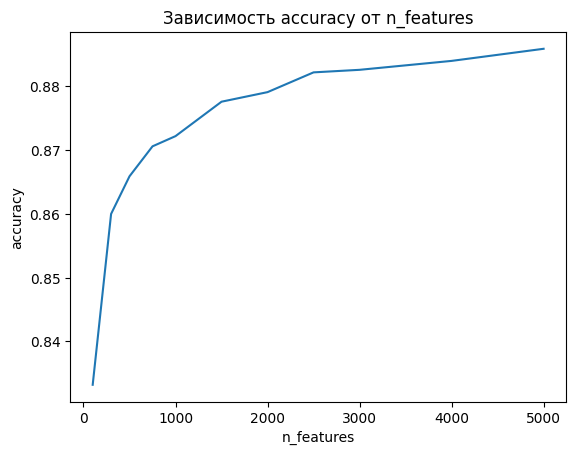

In [69]:
import matplotlib.pyplot as plt

plt.plot(n_list, acc)
plt.xlabel('n_features')
plt.ylabel('accuracy')
plt.title('Зависимость accuracy от n_features')
plt.show()

Accuracy так и не вышло на плато, оно растет вместе с ростом n_features

In [10]:
pipeline_svm = RFFPipeline(n_features=1000, new_dim=50, feature_creator_class=RandomFeatureCreator, classifier_class=SVC)
start = time.time()
pipeline_svm.fit(x_train, y_train)
y_pred = pipeline_svm.predict(x_test)
end = time.time()
print('RFF SVM Accuracy:', accuracy_score(y_pred, y_test))
print('Time:', end - start)

RFF SVM Accuracy: 0.868
Time: 361.80420780181885


При использовании SVM в качестве классификатора, accuracy получается немного меньше

__Бонус. (Максимум 1.75 балла)__

Как вы, должно быть, помните с курса МО-1, многие алгоритмы машинного обучения работают лучше, если признаки данных некоррелированы. Оказывается, что для RFF существует модификация, позволяющая получать ортогональные случайные признаки (Orthogonal Random Features, ORF). Об этом методе можно прочитать в [статье](https://proceedings.neurips.cc/paper/2016/file/53adaf494dc89ef7196d73636eb2451b-Paper.pdf). Реализуйте класс для вычисления ORF по аналогии с основным заданием. Обратите внимание, что ваш класс должен уметь работать со случаем n_features > new_dim (в статье есть замечание на этот счет), n_features=new_dim и n_features < new_dim также должны работать, убедитесь в этом. Проведите эксперименты, сравнивающие RFF и ORF, сделайте выводы. 


In [100]:
class OrthogonalRandomFeatureCreator(RandomFeatureCreator):
    def fit(self, X, y=None):
        i, j = np.random.randint(0, X.shape[0], 1000000), np.random.randint(0, X.shape[0], 1000000)
        mask = (i != j)
        i = i[mask]
        j = j[mask]
        sigma = np.median(((X[i] - X[j]) ** 2).sum(axis=1))
        self.b = np.random.uniform(-np.pi, np.pi, size=(self.n_features, ))
        if self.n_features <= self.new_dim:
            G = np.random.normal(0, 1, size=(self.new_dim, self.new_dim))
            Q, _ = np.linalg.qr(G)
            Q = Q[:self.n_features]
            S = np.sqrt(np.random.chisquare(self.new_dim, size=self.n_features))
            self.w = 1 / np.sqrt(sigma) * S[:, None] * Q
            return self

        n_blocks = self.n_features // self.new_dim + 1
        blocks = []
        for i in range(n_blocks):
            G = np.random.normal(0, 1, size=(self.new_dim, self.new_dim))
            Q, _ = np.linalg.qr(G)
            S = np.sqrt(np.random.chisquare(self.new_dim, size=self.new_dim))
            w = 1 / np.sqrt(sigma) * S[:, None] * Q
            blocks.append(w)
        self.w = np.concatenate(blocks, axis=0)[:self.n_features]
        return self

In [116]:
rff = RFFPipeline(n_features=1000, new_dim=50, feature_creator_class=RandomFeatureCreator, classifier_params={'C': 0.5, 'max_iter': 1000})
orf = RFFPipeline(n_features=1000, new_dim=50, feature_creator_class=OrthogonalRandomFeatureCreator, classifier_params={'C': 0.5, 'max_iter': 1000})

In [117]:
start_rff = time.time()
np.random.seed(42)
rff.fit(x_train, y_train)
y_pred_rff = rff.predict(x_test)
end_rff = time.time()

In [118]:
start_orf = time.time()
np.random.seed(42)
orf.fit(x_train, y_train)
y_pred_orf = orf.predict(x_test)
end_orf = time.time()

In [119]:
print('RFF accuracy:', accuracy_score(y_pred_rff, y_test))
print('Time:', end_rff - start_rff)
print('ORF accuracy:', accuracy_score(y_pred_orf, y_test))
print('Time:', end_orf - start_orf)

RFF accuracy: 0.8788
Time: 27.037293910980225
ORF accuracy: 0.8797
Time: 25.993860244750977


In [120]:
rff = RFFPipeline(n_features=50, new_dim=50, feature_creator_class=RandomFeatureCreator, classifier_params={'C': 0.5, 'max_iter': 1000})
orf = RFFPipeline(n_features=50, new_dim=50, feature_creator_class=OrthogonalRandomFeatureCreator, classifier_params={'C': 0.5, 'max_iter': 1000})

In [121]:
start_rff = time.time()
np.random.seed(42)
rff.fit(x_train, y_train)
y_pred_rff = rff.predict(x_test)
end_rff = time.time()

In [122]:
start_orf = time.time()
np.random.seed(42)
orf.fit(x_train, y_train)
y_pred_orf = orf.predict(x_test)
end_orf = time.time()

In [123]:
print('RFF accuracy:', accuracy_score(y_pred_rff, y_test))
print('Time:', end_rff - start_rff)
print('ORF accuracy:', accuracy_score(y_pred_orf, y_test))
print('Time:', end_orf - start_orf)

RFF accuracy: 0.8141
Time: 2.1035268306732178
ORF accuracy: 0.8148
Time: 1.6641550064086914


In [130]:
rff = RFFPipeline(n_features=40, new_dim=50, feature_creator_class=RandomFeatureCreator, classifier_params={'C': 0.5, 'max_iter': 1000})
orf = RFFPipeline(n_features=40, new_dim=50, feature_creator_class=OrthogonalRandomFeatureCreator, classifier_params={'C': 0.5, 'max_iter': 1000})

In [131]:
start_rff = time.time()
np.random.seed(42)
rff.fit(x_train, y_train)
y_pred_rff = rff.predict(x_test)
end_rff = time.time()

In [132]:
start_orf = time.time()
np.random.seed(42)
orf.fit(x_train, y_train)
y_pred_orf = orf.predict(x_test)
end_orf = time.time()

In [133]:
print('RFF accuracy:', accuracy_score(y_pred, y_test))
print('Time:', end_rff - start_rff)
print('ORF accuracy:', accuracy_score(y_pred, y_test))
print('Time:', end_orf - start_orf)

RFF accuracy: 0.1
Time: 2.246999979019165
ORF accuracy: 0.1
Time: 1.9419288635253906


Для случая D >= d при использовании ORF получается accuracy чуть больше чкм при использовании RFF. При D < d оба алгоритма дали одинаково плохой результат. Во всех случаях получилось, что на обучении ORF потребовалось меньше времени

__Бонус. (Максимум 1 балл)__

Существует большое количество работ, где идея RFF развивается, предлагаются её обобщения (которые, по сути, выливаются в другие преобразования признаков, не обязательно уже тригонометрические). Возьмите любую из таких работ, кратко опишите идею, имплементируйте её и сравните качество с ORF и RFF, которые вы запрограммировали выше.

Ссылки на статьи, где обсуждаются вариации RFF для разных ядер, можно найти в окрестности таблицы 1 в работе https://arxiv.org/pdf/1407.5599  

___ссылка на работу:___ https://dl.acm.org/doi/epdf/10.1145/2487575.2487591

___описание идеи:___ RFF для полиномиального ядра. $x^{(p)} = x \otimes  x  \otimes ... \otimes x \in \mathbb R^{d^p}$. Тогда скалярное произведение $<x^{(x)}, y^{(p)}>=<x,y>^p$ и есть значение полиномиального ядра для $x,y$. В работе предлагается не считать эти тензоры явно. Вместо это этого считаются Count Sketch тензоров с помощью Count Sketch и быстрого преобразования Фурье. Count Sketch точки $x \in \mathbb R^d$ - $Cx=\{ (Cx)_1, ..., (Cx)_k \} \in \mathbb R^k$, где $(Cx)_j = \sum_{i:h(i)=j} s(i)x_i$, h - хэш-функция, такая что $h:[d] \rightarrow [k]$, и s - хэш-функция, такая что $s: [d] \rightarrow \{-1, 1\}$.
Алгоритм:
D = n_features
p - степень полиномиального ядра
1) Выбираем p независимых хэш-функций $h_1, ..., h_p: [d] \rightarrow [D]$, где каждая функция из 2-универсального семейства
2) Выбираем p независимых хэш-функций $s_1, ..., s_p: [d] \rightarrow \{-1, 1\}$, где каждая функция из 2-универсального семейства
3) Для каждого $x$ считаем p разных Count Sketch. Получаем p разных Count Sketch векторов $C^{(1)}x, ..., C^{(p)}x$
4) К каждому Count Sketch вектору применяем быстрое преобразование Фурье
5) $f(x) = C^{(1)}x * ...* C^{(p)}x$, здесь умножение покомпонентное
6) Применяем обратное быстрое преобразование Фурье к $f(x)$. Это будет представление x в новом пространстве признаков

In [229]:
class HHash:
    def __init__(self, n_features, seed=42):
        self.n_features = n_features
        self.seed = seed
        self.j = 2 ** 61 - 1
        np.random.seed(self.seed)
        self.a = np.random.randint(0, self.j)
        self.b = np.random.randint(0, self.j)
    def hash(self, x):
        return (((self.a * x) + self.b) % self.j) % self.n_features


class SHash:
    def __init__(self, seed=42):
        self.seed = seed
        self.j = 2 ** 61 - 1
        np.random.seed(self.seed)
        self.a = np.random.randint(0, self.j)
        self.b = np.random.randint(0, self.j)
    def hash(self, x):
        if int((((self.a * x) + self.b) % self.j) % 2) == 1:
            return -1
        return 1

class PolynomKernelFeaturesCreator(BaseEstimator, TransformerMixin):
    def __init__(self, n_features, p):
        self.n_features = n_features
        self.p = p

        rnd_seeds = np.random.randint(low=0, high=100, size=(p, ))
        self.h_hash = []
        self.s_hash = []
        for seed in rnd_seeds:
            self.h_hash.append(HHash(n_features=self.n_features, seed=seed))
            self.s_hash.append(SHash(seed=seed))

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.astype(np.float64)
        sketches = np.zeros((self.p, X.shape[0], self.n_features))
        for deg in range(self.p):
            h = self.h_hash[deg]
            s = self.s_hash[deg]
            for j in range(X.shape[1]):
                bucket = h.hash(j)
                sign = s.hash(j)
                sketches[deg, :, bucket] += (sign * X[:, j])
        ffts = [np.fft.fft(sket, axis=1) for sket in sketches]
        mult = np.ones_like(ffts[0])
        for f in ffts:
            mult *= f
        tr = np.fft.ifft(mult, axis=1).real
        return tr

In [230]:
from sklearn.preprocessing import StandardScaler
class PolyKernelPipeline(BaseEstimator):
    def __init__(
            self,
            n_features: int = 1000,
            p: int = 10,
            feature_creator_class=PolynomKernelFeaturesCreator,
            classifier_class=LogisticRegression,
            classifier_params=None,
    ):
        self.n_features = n_features
        if classifier_params is None:
            classifier_params = {}
        self.classifier = classifier_class(**classifier_params)
        self.feature_creator_class = feature_creator_class
        self.pipeline = None
        self.p = p

    def fit(self, X, y):
        self.feature_creator = self.feature_creator_class(n_features=self.n_features, p=self.p)
        pipeline_steps: list[tuple] = [('poly', self.feature_creator), ('scaler', StandardScaler()), ('classfication', self.classifier)]
        self.pipeline = Pipeline(pipeline_steps).fit(X, y)
        return self

    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

    def predict(self, X):
        return self.pipeline.predict(X)

In [234]:
poly_rff = PolyKernelPipeline(n_features=1000, p=5, feature_creator_class=PolynomKernelFeaturesCreator, classifier_params={'C': 0.05, 'max_iter': 1000})

In [235]:
start_poly = time.time()
poly_rff.fit(x_train, y_train)
y_pred_poly = poly_rff.predict(x_test)
end_poly = time.time()

In [236]:
print('Polynomial Kernel accuracy:', accuracy_score(y_pred_poly, y_test))
print('Time:', end_poly-start_poly)

Polynomial Kernel accuracy: 0.2265
Time: 21.624639987945557


Результаты получились гораздо хуже чем при использовании RFF и ORF

__Задание 4. (Максимум 2.5 балла)__

Реализуйте класс ядровой Ridge регрессии (Лекция 13, $\S 1.2$), для оптимизации используте градиентный спуск **[1 балл максимум]**, также добавьте возможность использовать аналитическую формулу **[1 балл максимум]**. Для градиентного спуска выпишите градиент ниже **[0.5 баллов максимум]**. 
Подумайте о том, как в формулах правильно учесть свободный коэффициент. 

Затем адаптируйте вашу реализацию RFF под задачу регрессии. Сравните вашу ядровую регрессию и RFF на синтетических данных.

Функция потерь: 
$$
Q(w) = \frac{1}{2} ||\Phi \Phi^T w - y||^2 + \frac{\lambda}{2} w^T \Phi \Phi^T w \rightarrow \min_w,
$$
где $\Phi \Phi^T = K$, $K = (k(x_i, x_j))_{i, j = 1}^{\ell}$.

Предсказание: 
$
y(x) = k(x)^T w,
$
где $k(x)$ — вектор функций ядра от пар объектов $(x, x_i)_{i=1}^{\ell}$.

___Выведите градиент:___ 
$$
\nabla Q_w = \Phi \Phi^T ( \Phi \Phi^T w  - y) + \frac{\lambda}{2}(\Phi \Phi^T + (\Phi \Phi ^ T)^T)w
$$
$$
\nabla Q_w = \Phi \Phi^T ( \Phi \Phi^T w  - y) + \lambda \Phi \Phi^T w
$$

Вы можете изменять представленный шаблон в файле `homework_practice_11_kernel_regression.py` по своему усмотрению.

In [5]:
import numpy as np
from sklearn.base import RegressorMixin
from sklearn.gaussian_process.kernels import RBF


class KernelRidgeRegression(RegressorMixin):
    """
    Kernel Ridge regression class
    """

    def __init__(
        self,
        lr=0.01,
        regularization=1.0,
        tolerance=1e-2,
        max_iter=1000,
        batch_size=64,
        kernel_scale=1.0,
    ):
        """
        :param lr: learning rate
        :param regularization: regularization coefficient
        :param tolerance: stopping criterion for square of euclidean norm of weight difference
        :param max_iter: stopping criterion for iterations
        :param batch_size: size of the batches used in gradient descent steps
        :parame kernel_scale: length scale in RBF kernel formula
        """

        self.lr: float = lr
        self.regularization: float = regularization
        self.w: np.ndarray | None = None

        self.tolerance: float = tolerance
        self.max_iter: int = max_iter
        self.batch_size: int = batch_size
        self.loss_history: list[float] = []
        self.kernel = RBF(kernel_scale)

    def calc_loss(self, x: np.ndarray, y: np.ndarray) -> float:
        """
        Calculating loss for x and y dataset
        :param x: features array
        :param y: targets array
        """
        K = self.kernel(x)
        loss = 0.5 * np.linalg.norm(K @ self.w - y) ** 2 + 0.5 * self.regularization * self.w.T @ K @ self.w
        return loss


    def calc_grad(self, x: np.ndarray, y: np.ndarray) -> float:
        """
        Calculating gradient for x and y dataset
        :param x: features array
        :param y: targets array
        """
        K_batch = self.kernel(x, self.x_train)
        return K_batch.T @ (K_batch @ self.w - y) + self.regularization * self.K @ self.w

    def fit(self, x: np.ndarray, y: np.ndarray) -> "KernelRidgeRegression":
        """
        Получение параметров с помощью градиентного спуска
        :param x: features array
        :param y: targets array
        :return: self
        """
        i = 0
        self.w = np.zeros(x.shape[0])
        self.x_train = x
        self.K = self.kernel(x)
        while i < self.max_iter:
            batch_i = np.random.choice(x.shape[0], size=self.batch_size, replace=False)
            new_w = self.w - self.lr * self.calc_grad(x[batch_i], y[batch_i])
            if np.linalg.norm(new_w - self.w) < self.tolerance:
                self.w = new_w
                return self
            self.w = new_w
            i += 1
        return self

    def fit_closed_form(self, x: np.ndarray, y: np.ndarray) -> "KernelRidgeRegression":
        """
        Получение параметров через аналитическое решение
        :param x: features array
        :param y: targets array
        :return: self
        """
        K = self.kernel(x)
        self.x_train = x
        self.w = np.linalg.solve(K + self.regularization * np.identity(K.shape[0]), y)
        return self

    def predict(self, x: np.ndarray) -> np.ndarray:
        """
        Predicting targets for x dataset
        :param x: features array
        :return: prediction: np.ndarray
        """
        K = self.kernel(x, self.x_train)
        return K @ self.w

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
np.random.seed(42)
X = np.random.randn(10000, 50)
w = np.random.randn(50)
y = X @ w + np.random.randn(10000) * 0.1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
krr = KernelRidgeRegression(kernel_scale=7, lr=0.000001)
krr.fit(X_train, y_train)
y_pred = krr.predict(X_test)

In [9]:
K = krr.kernel(X_train[:1000])

print(K.mean())
print(K.min())
print(K.max())

0.3669590461011865
0.09457102402223956
1.0


In [12]:
from sklearn.metrics import mean_squared_error

print('KRR MSE:', mean_squared_error(y_test, y_pred))

KRR MSE: 53.65275576251097


In [54]:
from sklearn.svm import SVR
reg_rff = RFFPipeline(n_features=1000, new_dim=50, feature_creator_class=RandomFeatureCreator, classifier_class=SVR)
reg_rff.fit(X_train, y_train)
y_pred = reg_rff.predict(X_test)
print('RFF SVM MSE:', mean_squared_error(y_test, y_pred))

RFF SVM MSE: 1.0242220810935134
